# Bayesian Workflow Project: Modeling Ultra-Trail Running Race Times

## 1. Problem Formulation

### 1.1 Problem Statement

Ultra-trail running races (organized under the UTMB World Series) vary enormously in distance, elevation gain, and geographic location. We aim to build a **Bayesian regression model** that explains and predicts **Mean Finish Time** and **Winning Time** of races based on their physical characteristics (distance, elevation gain) and categorical attributes (race category).

The core question: *Given the distance and elevation gain of a trail race, what finishing times can we expect, and how uncertain are those predictions?*

### 1.2 Objectives and Use Cases

1. **Race organizers**: Predict expected finish times for new race courses to plan logistics (aid stations, cutoff times).
2. **Athletes**: Estimate expected finishing time based on course profile for pacing strategy.
3. **Understanding the sport**: Quantify the marginal effect of additional elevation gain on race duration.
4. **Model comparison**: Compare a simple Normal likelihood model with a Student-t model that accounts for outlier races.

### 1.3 Data Source

**Dataset**: UTMB World Race Data (Kaggle: `mgpoirot/utmb-world-race-daa`)

The dataset contains information about ultra-trail races worldwide from 2014–2024, including:
- Race identification (name, UID, year, country, continent)
- Physical characteristics (distance in km, elevation gain in m)
- Race category (20K, 50K, 100K, 100M)
- Timing results (mean finish time, winning time, last time — in decimal hours)
- Participation stats (number of participants, DNF count, women count, countries represented)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

# Load dataset
DATA_PATH = os.path.expanduser('~/.cache/kagglehub/datasets/mgpoirot/utmb-world-race-daa/versions/1')
if not os.path.exists(DATA_PATH):
    import kagglehub
    DATA_PATH = kagglehub.dataset_download('mgpoirot/utmb-world-race-daa')

csv_path = os.path.join(DATA_PATH, 'utmb-race-data-sheet.csv')
df_raw = pd.read_csv(csv_path, low_memory=False)
print(f"Raw dataset: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")

Raw dataset: 38,460 rows x 22 columns


In [2]:
df_raw.head()

,Race UID,Year,Day,Race Title,N Participants,Race Category,Distance,Elevation Gain,Mean Finish Time,Winning Time,...,N Women,N Countries,Raw Location,Administrative Level,Continent,Country,Elevation,Longitude,Latitude,Elevation Variance
0,10001,2017,309,Caravaca Trail Experience 2017 - Promo,292,-,12.0,400,2.0829,0.9050,...,142,1,Spain,1.0,EU,ES,594.10,-3.749220,40.463667,0.0
1,10003,2017,309,Caravaca Trail Experience 2017 - Master,163,50K,35.2,2030,4.9722,3.1583,...,26,3,Spain,1.0,EU,ES,594.10,-3.749220,40.463667,0.0
2,10003,2018,301,Caravaca Trail Experience 2018 - Master,81,50K,34.5,1630,4.5411,3.3642,...,10,2,Spain,1.0,EU,ES,594.10,-3.749220,40.463667,0.0
3,10003,2019,300,Caravaca Trail Experience 2019 - MASTER,65,50K,34.6,1630,4.5033,3.2142,...,8,2,Spain,1.0,EU,ES,594.10,-3.749220,40.463667,0.0
4,10005,2017,287,The Red Leaves Trail Running Race 2017 - 25KM,53,20K,27.2,1660,6.3384,3.4475,...,20,1,China,1.0,AS,CN,1840.54,104.195397,35.861660,0.0


### 1.4 Data Preprocessing

We need to:
1. Select relevant columns for our modeling task
2. Remove rows with missing values in target and predictor columns
3. Filter to main race categories (20K, 50K, 100K, 100M)
4. Remove extreme outliers (data entry errors)
5. Standardize predictors for better prior specification

In [3]:
# Select relevant columns
cols = ['Race Category', 'Distance', 'Elevation Gain', 'Mean Finish Time', 
        'Winning Time', 'N Participants', 'Year', 'Country', 'Elevation']
df = df_raw[cols].copy()

print("Before cleaning:")
print(f"  Shape: {df.shape}")
print(f"  Missing values:")
print(df.isnull().sum().to_string())

Before cleaning:
  Shape: (38460, 9)
  Missing values:
Race Category        0
Distance             0
Elevation Gain       0
Mean Finish Time    51
Winning Time        51
N Participants       0
Year                 0
Country              7
Elevation            0


In [4]:
# Step 1: Keep only main categories
main_cats = ['20K', '50K', '100K', '100M']
df = df[df['Race Category'].isin(main_cats)].copy()

# Step 2: Drop rows with missing target or predictor values
df = df.dropna(subset=['Mean Finish Time', 'Winning Time', 'Distance', 'Elevation Gain'])

# Step 3: Remove physically impossible / data-entry-error rows
# Winning time must be positive and less than mean finish time
df = df[(df['Winning Time'] > 0) & (df['Mean Finish Time'] > 0)]
df = df[df['Winning Time'] <= df['Mean Finish Time']]

# Remove extreme outliers: distance > 300km or elevation > 20000m are likely errors
df = df[(df['Distance'] > 5) & (df['Distance'] < 300)]
# Lower bound 100 m: races with < 100 m elevation gain are almost certainly
# data-entry errors in a mountain/trail race dataset. log(0+1)=0 would place them
# 9+ SD below the mean on the log-elevation scale, creating extreme leverage.
df = df[(df['Elevation Gain'] >= 100) & (df['Elevation Gain'] < 20000)]

# Remove unrealistic finish times (> 80 hours even for 100M is extreme)
df = df[df['Mean Finish Time'] < 80]
df = df[df['Winning Time'] < 50]

# Derived feature: elevation gained per 1 km (m/km)
df['Elevation per km'] = df['Elevation Gain'] / df['Distance']

print(f"\nAfter cleaning: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nCategory distribution:")
print(df['Race Category'].value_counts().to_string())


After cleaning: 36,433 rows x 10 columns

Category distribution:
50K     15487
20K     10765
100K     7391
100M     2790


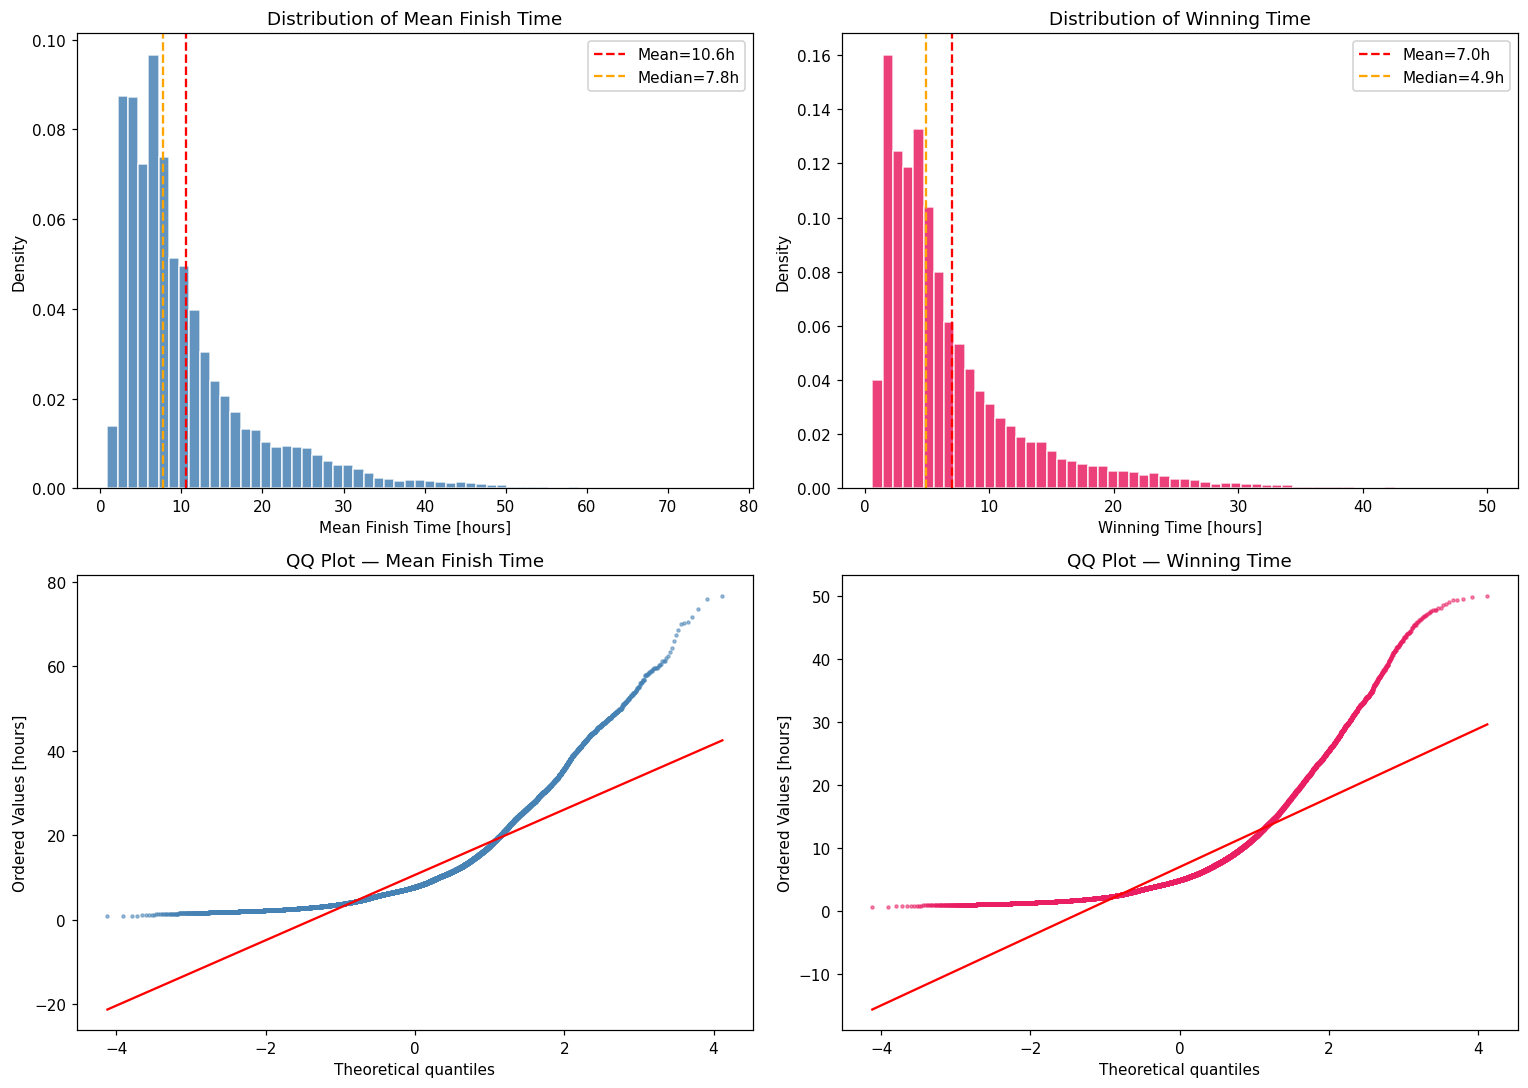


=== Mean Finish Time ===
  Mean:     10.62 h
  Std:      8.64 h
  Skewness: 1.994
  Kurtosis: 4.941
  Min:      0.87 h
  Max:      76.73 h

=== Winning Time ===
  Mean:     7.02 h
  Std:      6.24 h
  Skewness: 2.232
  Kurtosis: 6.412
  Min:      0.61 h
  Max:      49.99 h


In [5]:
# Examine target variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Mean Finish Time histogram
axes[0,0].hist(df['Mean Finish Time'], bins=60, color='steelblue', edgecolor='white', alpha=0.85, density=True)
axes[0,0].axvline(df['Mean Finish Time'].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Mean={df['Mean Finish Time'].mean():.1f}h")
axes[0,0].axvline(df['Mean Finish Time'].median(), color='orange', linestyle='--', linewidth=1.5, label=f"Median={df['Mean Finish Time'].median():.1f}h")
axes[0,0].set_xlabel('Mean Finish Time [hours]')
axes[0,0].set_ylabel('Density')
axes[0,0].set_title('Distribution of Mean Finish Time')
axes[0,0].legend(framealpha=0.9)

# Winning Time histogram
axes[0,1].hist(df['Winning Time'], bins=60, color='#E91E63', edgecolor='white', alpha=0.85, density=True)
axes[0,1].axvline(df['Winning Time'].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Mean={df['Winning Time'].mean():.1f}h")
axes[0,1].axvline(df['Winning Time'].median(), color='orange', linestyle='--', linewidth=1.5, label=f"Median={df['Winning Time'].median():.1f}h")
axes[0,1].set_xlabel('Winning Time [hours]')
axes[0,1].set_ylabel('Density')
axes[0,1].set_title('Distribution of Winning Time')
axes[0,1].legend(framealpha=0.9)

# QQ plots with improved styling
stats.probplot(df['Mean Finish Time'], plot=axes[1,0])
axes[1,0].get_lines()[0].set(color='steelblue', markersize=2, alpha=0.5)
axes[1,0].get_lines()[1].set(color='red', linewidth=1.5)
axes[1,0].set_title('QQ Plot — Mean Finish Time')
axes[1,0].set_ylabel('Ordered Values [hours]')

stats.probplot(df['Winning Time'], plot=axes[1,1])
axes[1,1].get_lines()[0].set(color='#E91E63', markersize=2, alpha=0.5)
axes[1,1].get_lines()[1].set(color='red', linewidth=1.5)
axes[1,1].set_title('QQ Plot — Winning Time')
axes[1,1].set_ylabel('Ordered Values [hours]')

plt.tight_layout()
plt.savefig('fig01_target_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Mean Finish Time ===")
print(f"  Mean:     {df['Mean Finish Time'].mean():.2f} h")
print(f"  Std:      {df['Mean Finish Time'].std():.2f} h")
print(f"  Skewness: {df['Mean Finish Time'].skew():.3f}")
print(f"  Kurtosis: {df['Mean Finish Time'].kurtosis():.3f}")
print(f"  Min:      {df['Mean Finish Time'].min():.2f} h")
print(f"  Max:      {df['Mean Finish Time'].max():.2f} h")

print("\n=== Winning Time ===")
print(f"  Mean:     {df['Winning Time'].mean():.2f} h")
print(f"  Std:      {df['Winning Time'].std():.2f} h")
print(f"  Skewness: {df['Winning Time'].skew():.3f}")
print(f"  Kurtosis: {df['Winning Time'].kurtosis():.3f}")
print(f"  Min:      {df['Winning Time'].min():.2f} h")
print(f"  Max:      {df['Winning Time'].max():.2f} h")

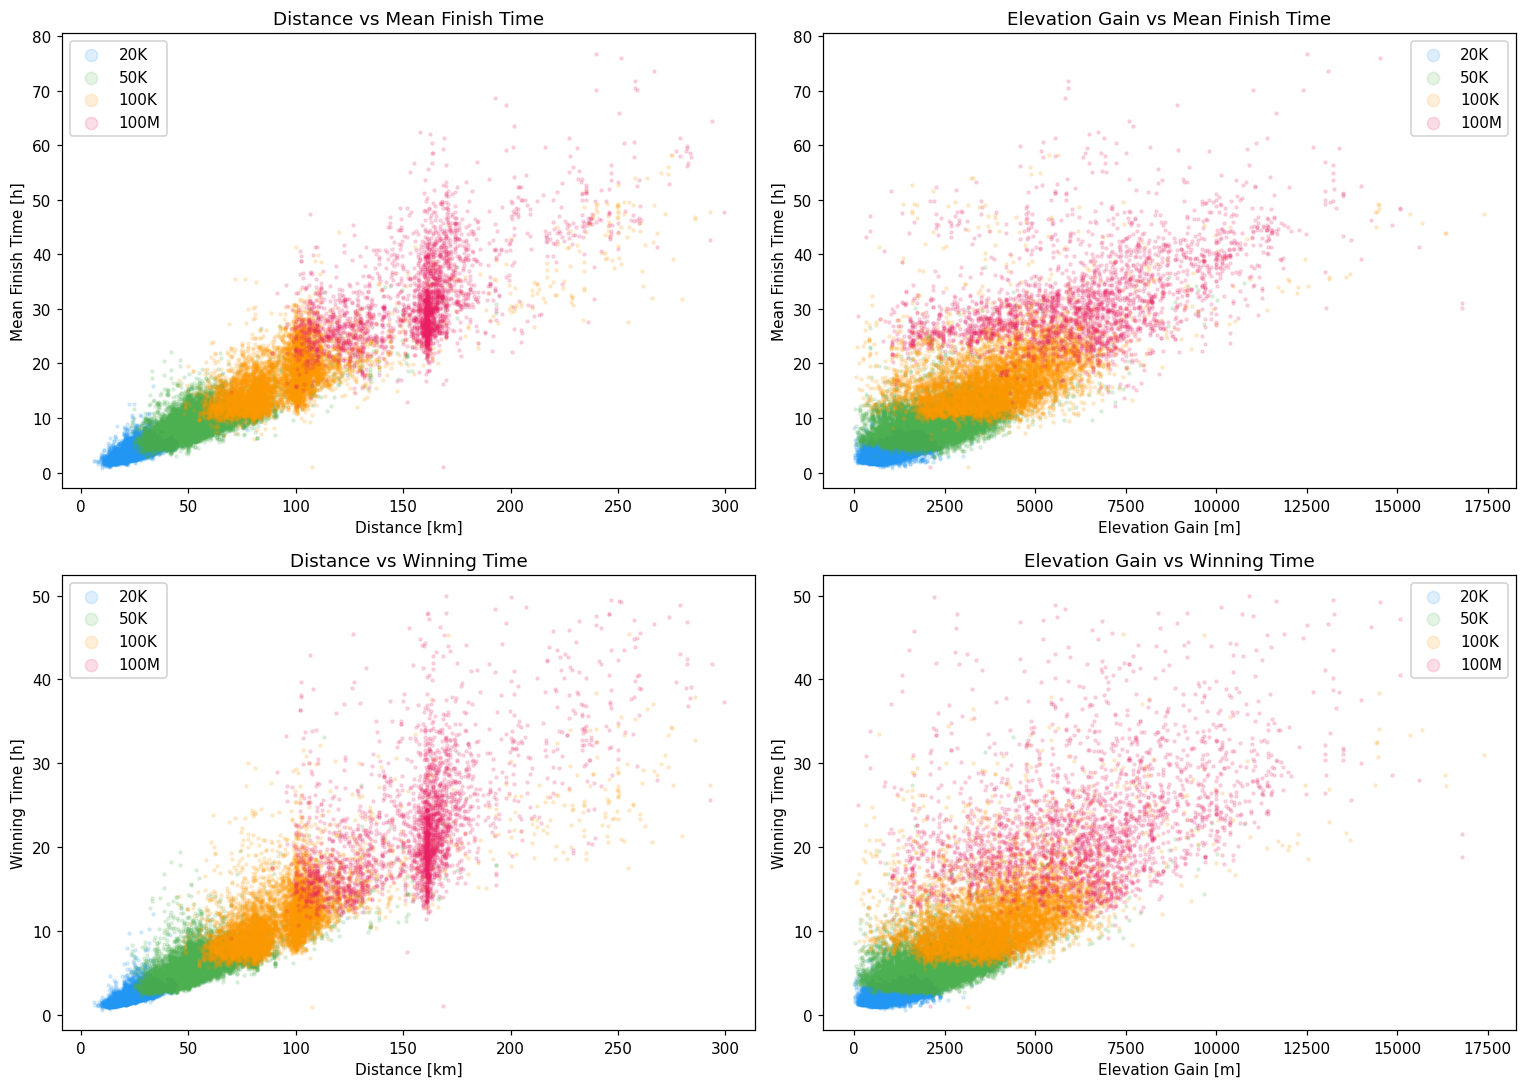

In [6]:
# Examine predictors and their relationship to targets
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors_cats = {'20K': '#2196F3', '50K': '#4CAF50', '100K': '#FF9800', '100M': '#E91E63'}

# Use smaller markers and lower alpha for 36K points to reduce overplotting
for cat in main_cats:
    sub = df[df['Race Category'] == cat]
    axes[0,0].scatter(sub['Distance'], sub['Mean Finish Time'], 
                      c=colors_cats[cat], alpha=0.15, s=4, label=cat, rasterized=True)
axes[0,0].set_xlabel('Distance [km]')
axes[0,0].set_ylabel('Mean Finish Time [h]')
axes[0,0].set_title('Distance vs Mean Finish Time')
axes[0,0].legend(markerscale=4, framealpha=0.9)

for cat in main_cats:
    sub = df[df['Race Category'] == cat]
    axes[0,1].scatter(sub['Elevation Gain'], sub['Mean Finish Time'],
                      c=colors_cats[cat], alpha=0.15, s=4, label=cat, rasterized=True)
axes[0,1].set_xlabel('Elevation Gain [m]')
axes[0,1].set_ylabel('Mean Finish Time [h]')
axes[0,1].set_title('Elevation Gain vs Mean Finish Time')
axes[0,1].legend(markerscale=4, framealpha=0.9)

for cat in main_cats:
    sub = df[df['Race Category'] == cat]
    axes[1,0].scatter(sub['Distance'], sub['Winning Time'],
                      c=colors_cats[cat], alpha=0.15, s=4, label=cat, rasterized=True)
axes[1,0].set_xlabel('Distance [km]')
axes[1,0].set_ylabel('Winning Time [h]')
axes[1,0].set_title('Distance vs Winning Time')
axes[1,0].legend(markerscale=4, framealpha=0.9)

for cat in main_cats:
    sub = df[df['Race Category'] == cat]
    axes[1,1].scatter(sub['Elevation Gain'], sub['Winning Time'],
                      c=colors_cats[cat], alpha=0.15, s=4, label=cat, rasterized=True)
axes[1,1].set_xlabel('Elevation Gain [m]')
axes[1,1].set_ylabel('Winning Time [h]')
axes[1,1].set_title('Elevation Gain vs Winning Time')
axes[1,1].legend(markerscale=4, framealpha=0.9)

plt.tight_layout()
plt.savefig('fig02_predictors_vs_targets.png', dpi=150, bbox_inches='tight')
plt.show()

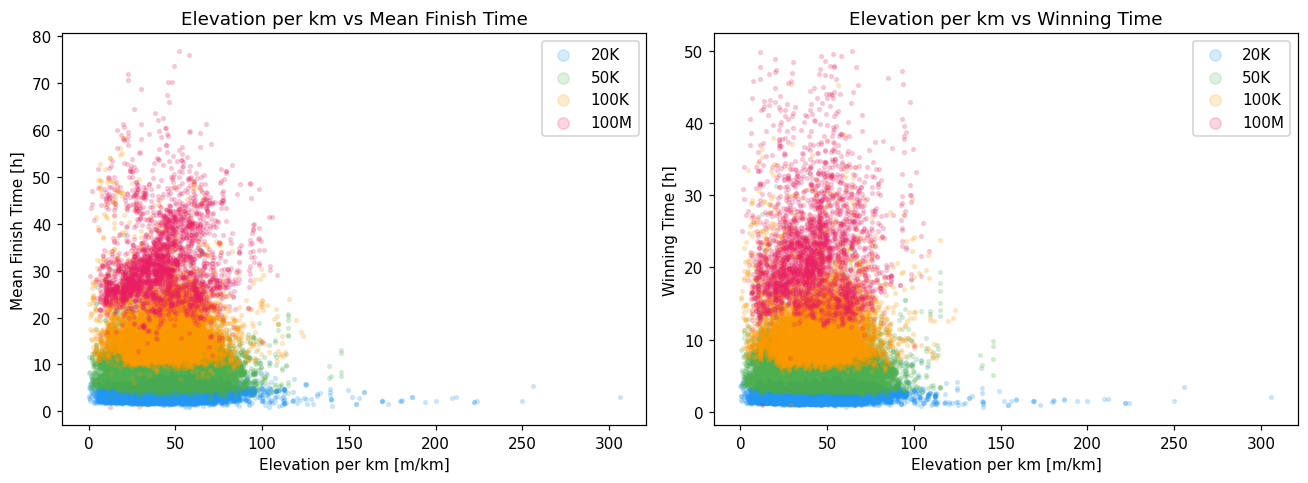

Elevation per km summary (m/km):
count    36433.00
mean        44.48
std         19.27
min          0.03
25%         30.74
50%         44.00
75%         57.03
max        306.12


In [7]:
# Elevation per km vs targets
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for cat in main_cats:
    sub = df[df['Race Category'] == cat]
    axes[0].scatter(sub['Elevation per km'], sub['Mean Finish Time'],
                    c=colors_cats[cat], alpha=0.18, s=6, label=cat, rasterized=True)
axes[0].set_xlabel('Elevation per km [m/km]')
axes[0].set_ylabel('Mean Finish Time [h]')
axes[0].set_title('Elevation per km vs Mean Finish Time')
axes[0].legend(markerscale=3, framealpha=0.9)

for cat in main_cats:
    sub = df[df['Race Category'] == cat]
    axes[1].scatter(sub['Elevation per km'], sub['Winning Time'],
                    c=colors_cats[cat], alpha=0.18, s=6, label=cat, rasterized=True)
axes[1].set_xlabel('Elevation per km [m/km]')
axes[1].set_ylabel('Winning Time [h]')
axes[1].set_title('Elevation per km vs Winning Time')
axes[1].legend(markerscale=3, framealpha=0.9)

plt.tight_layout()
plt.savefig('fig02b_elevation_per_km_vs_targets.png', dpi=150, bbox_inches='tight')
plt.show()

print("Elevation per km summary (m/km):")
print(df['Elevation per km'].describe().round(2).to_string())

In [10]:
# Correlations between predictors and targets
corr_cols = ['Distance', 'Elevation Gain', 'Elevation per km', 'Mean Finish Time', 'Winning Time']
corr = df[corr_cols].corr()
print("Correlation matrix:")
print(corr.round(3).to_string())

print(f"\n\nKey observations:")
print(f"  Distance ↔ Mean Finish Time:        r = {corr.loc['Distance','Mean Finish Time']:.3f}")
print(f"  Elevation Gain ↔ Mean Finish Time:  r = {corr.loc['Elevation Gain','Mean Finish Time']:.3f}")
print(f"  Elevation per km ↔ Mean Finish Time: r = {corr.loc['Elevation per km','Mean Finish Time']:.3f}")
print(f"  Distance ↔ Winning Time:            r = {corr.loc['Distance','Winning Time']:.3f}")
print(f"  Elevation Gain ↔ Winning Time:      r = {corr.loc['Elevation Gain','Winning Time']:.3f}")
print(f"  Elevation per km ↔ Winning Time:    r = {corr.loc['Elevation per km','Winning Time']:.3f}")
print(f"  Distance ↔ Elevation Gain:          r = {corr.loc['Distance','Elevation Gain']:.3f}")
print(f"  Distance ↔ Elevation per km:        r = {corr.loc['Distance','Elevation per km']:.3f}")
print(f"  Elevation Gain ↔ Elevation per km:  r = {corr.loc['Elevation Gain','Elevation per km']:.3f}")


Correlation matrix:
                  Distance  Elevation Gain  Elevation per km  Mean Finish Time  Winning Time
Distance             1.000           0.727            -0.209             0.937         0.922
Elevation Gain       0.727           1.000             0.382             0.821         0.805
Elevation per km    -0.209           0.382             1.000            -0.030        -0.032
Mean Finish Time     0.937           0.821            -0.030             1.000         0.969
Winning Time         0.922           0.805            -0.032             0.969         1.000


Key observations:
  Distance ↔ Mean Finish Time:        r = 0.937
  Elevation Gain ↔ Mean Finish Time:  r = 0.821
  Elevation per km ↔ Mean Finish Time: r = -0.030
  Distance ↔ Winning Time:            r = 0.922
  Elevation Gain ↔ Winning Time:      r = 0.805
  Elevation per km ↔ Winning Time:    r = -0.032
  Distance ↔ Elevation Gain:          r = 0.727
  Distance ↔ Elevation per km:        r = -0.209
  Elevation Ga

In [13]:
# -----------------------------------------------------------------------------
# Feature engineering for the LOG-TIME workflow
# -----------------------------------------------------------------------------
# Finish time is strictly positive, so we model log(time) and back-transform with
# exp() to guarantee positive predictions. Predictors are log-transformed too,
# giving regression coefficients a multiplicative interpretation on the time scale.

# Log-transformed target and predictors
df['log_time'] = np.log(df['Mean Finish Time'])
df['log_distance'] = np.log(df['Distance'])
df['log_elevation_gain'] = np.log(df['Elevation Gain'] + 1)   # +1 guards against elevation 0
df['log_elevation'] = np.log(df['Elevation'] + 1)           # +1 guards against elevation 0 or negative

# Route steepness: elevation gain per km (already present as 'Elevation per km')
df['steepness'] = df['Elevation Gain'] / df['Distance']

# Legacy linear-scale standardization (kept for reference / backwards compatibility)
df['distance_std'] = (df['Distance'] - df['Distance'].mean()) / df['Distance'].std()
df['elevation_gain_std'] = (df['Elevation Gain'] - df['Elevation Gain'].mean()) / df['Elevation Gain'].std()

# Log-scale standardization -- these are the predictors used by the models
def standardise(s): return (s - s.mean()) / s.std()

df['distance_log_std']  = standardise(df['log_distance'])
df['elevation_gain_log_std'] = standardise(df['log_elevation_gain'])
df['log_steepness']     = np.log1p(df['steepness'])   # compress extreme outliers
df['steepness_std']     = standardise(df['log_steepness'])
df['elevation_log_std'] = standardise(df['log_elevation'])

# Altitude above sea level (m). The raw Kaggle column is 'Elevation'.
# If absent (old CSV without the column), create a zeros placeholder and warn.
# Altitude: log1p-transform before standardising.
# Raw altitude has a +9.6 SD outlier (very high-altitude race); log1p compresses
# this to ~3-4 SD, consistent with the other log1p-transformed predictors.
if 'Elevation' in df.columns:
    df['log_altitude'] = np.log1p(df['Elevation'])
    df['altitude_std'] = standardise(df['log_altitude'])
else:
    import warnings
    warnings.warn("Column 'Elevation' (altitude a.s.l.) missing — 'altitude_std' set to 0. "
                  "Re-run after adding the column to the raw data.")
    df['log_altitude'] = 0.0
    df['altitude_std'] = 0.0

print("Log-scale standardized predictors (used by the models):")
print(f"  distance_log_std:  mean={df['distance_log_std'].mean():.4f}, std={df['distance_log_std'].std():.4f}")
print(f"  elevation_gain_log_std: mean={df['elevation_gain_log_std'].mean():.4f}, std={df['elevation_gain_log_std'].std():.4f}")
print(f"  steepness_std:     mean={df['steepness_std'].mean():.4f}, std={df['steepness_std'].std():.4f}")
print(f"  altitude_std:      mean={df['altitude_std'].mean():.4f}, std={df['altitude_std'].std():.4f}")

print(f"\nTarget on the log scale:")
print(f"  log_time: mean={df['log_time'].mean():.3f}, std={df['log_time'].std():.3f}  "
      f"(=> typical time exp(mean) = {np.exp(df['log_time'].mean()):.2f} h)")

print(f"\nScale reference:")
print(f"  Distance:  mean={df['Distance'].mean():.1f} km, std={df['Distance'].std():.1f} km")
print(f"  Elevation: mean={df['Elevation Gain'].mean():.0f} m, std={df['Elevation Gain'].std():.0f} m")
print(f"  Steepness: mean={df['steepness'].mean():.1f} m/km, std={df['steepness'].std():.1f} m/km")

# Save processed data
df.to_csv('utmb_processed.csv', index=False)
print(f"\nProcessed data saved: {df.shape[0]:,} rows, {df.shape[1]} columns")

Log-scale standardized predictors (used by the models):
  distance_log_std:  mean=-0.0000, std=1.0000
  elevation_gain_log_std: mean=-0.0000, std=1.0000
  steepness_std:     mean=-0.0000, std=1.0000
  altitude_std:      mean=0.0000, std=1.0000

Target on the log scale:
  log_time: mean=2.095, std=0.723  (=> typical time exp(mean) = 8.13 h)

Scale reference:
  Distance:  mean=60.3 km, std=40.5 km
  Elevation: mean=2518 m, std=1865 m
  Steepness: mean=44.5 m/km, std=19.3 m/km

Processed data saved: 36,433 rows, 24 columns


In [12]:
df.head()

,Race Category,Distance,Elevation Gain,Mean Finish Time,Winning Time,N Participants,Year,Country,Elevation,Elevation per km,...,log_distance,log_elevation,steepness,distance_std,elevation_std,distance_log_std,elevation_log_std,log_steepness,steepness_std,altitude_std
1,50K,35.2,2030,4.9722,3.1583,163,2017,ES,594.10,57.670455,...,3.561046,7.616284,57.670455,-0.619089,-0.261783,-0.548826,0.046309,4.071936,0.712529,0.092551
2,50K,34.5,1630,4.5411,3.3642,81,2018,ES,594.10,47.246377,...,3.540959,7.396949,47.246377,-0.636365,-0.476259,-0.581064,-0.253179,3.876321,0.328911,0.092551
3,50K,34.6,1630,4.5033,3.2142,65,2019,ES,594.10,47.109827,...,3.543854,7.396949,47.109827,-0.633897,-0.476259,-0.576419,-0.253179,3.873486,0.323353,0.092551
4,20K,27.2,1660,6.3384,3.4475,53,2017,CN,1840.54,61.029412,...,3.303217,7.415175,61.029412,-0.816524,-0.460174,-0.962616,-0.228292,4.127609,0.821707,2.185846
5,20K,28.1,1750,5.5513,3.3089,44,2018,CN,1840.54,62.277580,...,3.335770,7.467942,62.277580,-0.794313,-0.411916,-0.910372,-0.156242,4.147531,0.860777,2.185846


### 1.5 Summary of Data Characteristics

**Target variables:**
- `Mean Finish Time` — continuous, positive, right-skewed (longer races have more spread)
- `Winning Time` — continuous, positive, right-skewed, lower variance than mean finish time

**Key observations from QQ plots:**
- Both targets show deviation from normality in the tails (heavy right tail)
- Some outlier races exist with unexpectedly high or low times
- This suggests a **Student-t likelihood** may be more appropriate than Normal

**Predictors:**
- `Distance` (km) — strong linear relationship with both targets (r ≈ 0.85-0.90)
- `Elevation Gain` (m) — moderate relationship (r ≈ 0.65-0.75)
- Both predictors are correlated with each other (r ≈ 0.75)

**Modeling implications:**
- Finish time is **strictly positive and right-skewed** → modelling it directly with a Normal/Student-t likelihood (defined on the whole real line) could produce impossible negative times. We therefore model **`log_time = log(Mean Finish Time)`** and back-transform predictions with `exp()`.
- On the log scale the relationship with distance/elevation is closer to linear, and coefficients become **multiplicative** time factors.
- Presence of outlier races → a **Student-t** likelihood (on the log scale) is more robust.
- Heteroscedasticity on the hour scale is largely absorbed by the log transform (constant multiplicative spread).

**Decision**: We model **`log(Mean Finish Time)`** as the primary target, with log-transformed, standardized predictors. We fit two models that share the **same four predictors**:
1. **Model 1**: Normal likelihood on log-time.
2. **Model 2**: Student-t likelihood on log-time (robust to outliers).

Both use: `distance_log_std`, `elevation_log_std`, `steepness_std` (log1p of elevation per km), and `altitude_std` (altitude above sea level — hypoxia effect).

The derived columns saved to `utmb_processed.csv` are the inputs used throughout notebooks 02–05.
**Note**: the `Elevation` column (altitude a.s.l.) must be present in the raw data for `altitude_std` to be meaningful; if absent, it defaults to 0 (placeholder).